# Fund Workstation

## Pre-Analysis Loading

#### Environment Setting

In [1]:
import pandas as pd
import plotly.graph_objects as go
from src.fofproject.fund import Fund, input_monthly_returns, subset_of_funds, compare_funds
from fofproject.batch import plot_cumulative_returns, plot_fund_correlation_heatmap
from src.fofproject.mvo import minimum_variance_analysis
from src.fofproject.load import load_saved_json, init_funds, process_pdfs_in_folder, save_changes_in_fund, merge_funds, rerun_no_perf_files, continue_running

# Names of our portfolio & benchmark indices
our_portfolio = ['TAIREN','HAO','LEXINGTON','LIM','FOREST','WT CHINA','E20','3W GLOBAL','3W CHINA','3W HEALTHCARE','TIMEFOLIO','MONOLITH','PERSEVERANCE','NEO IVY','JH BIOTECH']
our_index = ['EUREKAHEDGE WORLD', 'MSCI CHINA',	'MSCI WORLD', 'EUREKAHEDGE ASIA', 'TOPIX', 'S&P 500', 'SOX', 'KOSPI', 'TAIEX', 'MSCI EM', 'RUSSELL 2000', 'STOXX 600', 'STOXX 50', 'FTSE UK', 'US HEALTHCARE', 'US FINANCIAL', 'US ENERGY', 'COMMODITY']

#### Load Data via .json

In [ ]:
test = load_saved_json(folder_path=r"input\sg_ms_manager")
funds = init_funds(test)


In [3]:
port = load_saved_json(folder_path=r"input\portfolio")
funds = init_funds(port)


#### Load Data via .csv

In [2]:
# Use for manually update csv data and merge with json file 
csv_fund = input_monthly_returns(r"RETURN DATA.csv")

#### GPT Input Factsheet

##### Parse Everything

In [ ]:
# Do not open the pdf while running, or the renaming process will encounter error
gpt_fund = process_pdfs_in_folder(folder_path=r"input\marex",save=True)
funds = init_funds(gpt_fund)

##### Continue Running Unparsed

In [3]:
gpt_fund_2 = continue_running(folder_path=r"input\marex",save=True)
funds = init_funds(gpt_fund_2)

Processing: input\marex\Marex - Alba.pdf
Only one year 2025 found in table of ALBA CREDIT, returned empty list
Processing: input\marex\Marex - Aspen Global.pdf
Processing: input\marex\Marex - Gembridge.pdf
Processing: input\marex\Marex - Metrica.pdf


In [ ]:
gpt_fund = gpt_fund_2 | gpt_fund

##### Re-Run No Performance Funds

In [ ]:
# Target the files with "No Performance Found", and re-run the analysis again
rerun_no_perf_files(folder_path=r"input\worth_a_look",save=True)

#### Merging Different Input

In [4]:
# Use the left hand's PERFORMANCE TABLE to update the right hand one
funds = merge_funds(csv_fund, funds)

In [ ]:
# Right-hand side has higher priority
funds = funds | funds

#### Save the Changes to .json & .csv

In [ ]:
# Careful what fund you are saving to what folder
save_changes_in_fund(funds, folder_path=r"input\worth_a_look")

In [ ]:
print(funds['ASIAN TECHNOLOGY'].total_max_dd)

## Fund Analysis

#### Dataframe Comparison

In [5]:
df = compare_funds(funds)
do_not_display = our_index + our_portfolio
df = df[~df["Name"].isin(do_not_display)].reset_index(drop=True)
df.head(3)

,Name,Description,Location,Strategy,Sector,Managers,Contact,AUM (in Mn USD),Net Exposure,Net Return,...,Latest Date,Month Running,# Months,Cumulative Return,Annualized Return,Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Positive Months
0,EUREKAHEDGE,None,None,None,None,None,No contact info,NaN,No net exposure info,None,...,2025-08-01,92.3,92,0.490844,0.053469,0.074809,0.714736,1.200896,0.138768,0.586957
1,RDGFF,None,None,None,None,None,No contact info,NaN,No net exposure info,None,...,2025-08-01,92.3,92,1.933094,0.150683,0.102486,1.470273,3.198801,0.078768,0.684783


In [ ]:
# Column List = ["Name", "Description", "Location", "Strategy", "Sector", "Managers", "Contact", "AUM (in Mn USD)", 
#                     "Net Exposure", "Net Return", "Mgmt Fee", "Perf Fee", "Inception Date", "Latest Date", "Month Running",
#                     "# Months", "Cumulative Return", "Annualized Return", "Volatility", "Sharpe Ratio", 
#                     "Sortino Ratio", "Max Drawdown", "Positive Months"]


In [ ]:
# sort by what we think important   
df = df.sort_values(by=["Sharpe Ratio", "Annualized Return"], ascending=[False, False])
# mask and filtered only the wanted funds
mask =  (df["Month Running"] > 12) & (df["Annualized Return"] > 0.14)
df['Worth a Look'] = mask
# Display only the following columns
display_df = df[["Worth a Look","Name", "Sharpe Ratio", "Annualized Return", "AUM (in Mn USD)", "Month Running","Description","Max Drawdown" ]]
display_df


#### Save it to CSV

In [ ]:
# Select the column you want to save
output_df = df[["Worth a Look","Name", "Sharpe Ratio", "Annualized Return", "AUM (in Mn USD)", "Month Running","Max Drawdown" ,"Net Exposure","Strategy", "Sector","Contact","Description", "Mgmt Fee", "Perf Fee"]]
output_df.to_csv("output/funds_comparison.csv", index=False)

#### Save it to a list

In [ ]:
exclude_list = our_index + our_portfolio
df = df[~df["Name"].isin(exclude_list)].reset_index(drop=True)
worth_looking = df.loc[df["Worth a Look"], "Name"].tolist()
print(worth_looking)

#### Compare Performance Table

In [ ]:
funds['ONELS'].export_monthly_table(benchmark_fund = funds['MSCI CHINA'], benchmark_name = "MSCI\nChina" ,language = "en", inception_column = True)

#### Plot Cumulative Return

In [12]:

funds_to_be_plot = subset_of_funds(funds, ['RDGFF', 'SOX', 'US FINANCIAL'])
start_month = "2015-12"
end_month = "2025-9"

plot = plot_cumulative_returns(
    funds=funds_to_be_plot,
    title="",
    start_month=start_month,
    end_month=end_month,
    style="excel",
    language="en",
    blur=False,
    aspect_lock=True,
    custom_ticks=False,
    save=False,
    toggle=False
    )


#### Correlation Heat Map

In [ ]:
# Correlation heatmap

start_month = "2019-12"
end_month = "2025-7"

fig, corr_df, overlap_df = plot_fund_correlation_heatmap(funds_to_be_plot, method="pearson", min_overlap=12)

#### Efficient Frontier Analysis

In [ ]:
remove_list = ['E20', 'PERSEVERANCE']

for i, k in enumerate(our_portfolio):
    if k in remove_list:
        our_portfolio.pop(i)
print(our_portfolio)


funds_to_be_plot = subset_of_funds(funds, our_portfolio)

In [ ]:
# Choose Mode between "Maximum Sharpe", "Minimum Variance", "Target Return"
fig, weights, stats = minimum_variance_analysis(funds=funds_to_be_plot, mode="Maximum Sharpe", title=None)
print(weights)
print(stats)

#### Summary of a Fund

In [13]:
funds['RDGFF'].annualized_return("2023-04",funds['ONELS'].latest_date)

KeyError: 'ONELS'

METRICA ASIA EVENT DRIVEN MASTER FUND is an event-driven and relative value fund focused on Asian equity markets including Japan. It targets low-volatility, market-neutral returns by investing in securities affected by corporate actions, ownership links, and common issuers. The fund has a target gross exposure of 200% and net exposure range of -50% to 50%, with an average net exposure of 20%. The fund is managed by Damian L. Edwards, a CIO with 21 years of experience. Rating: 4, overall positive view.
Net Exposure = -50.0% to 50.0%
David Mulvenna - Based in Singapore, try reachout via email 'david.mulvenna@metricapartners.com' or phone '+65 6904 1992'
Chart saved to METRICA_vs_MSCI CHINA_worst_ranked.png


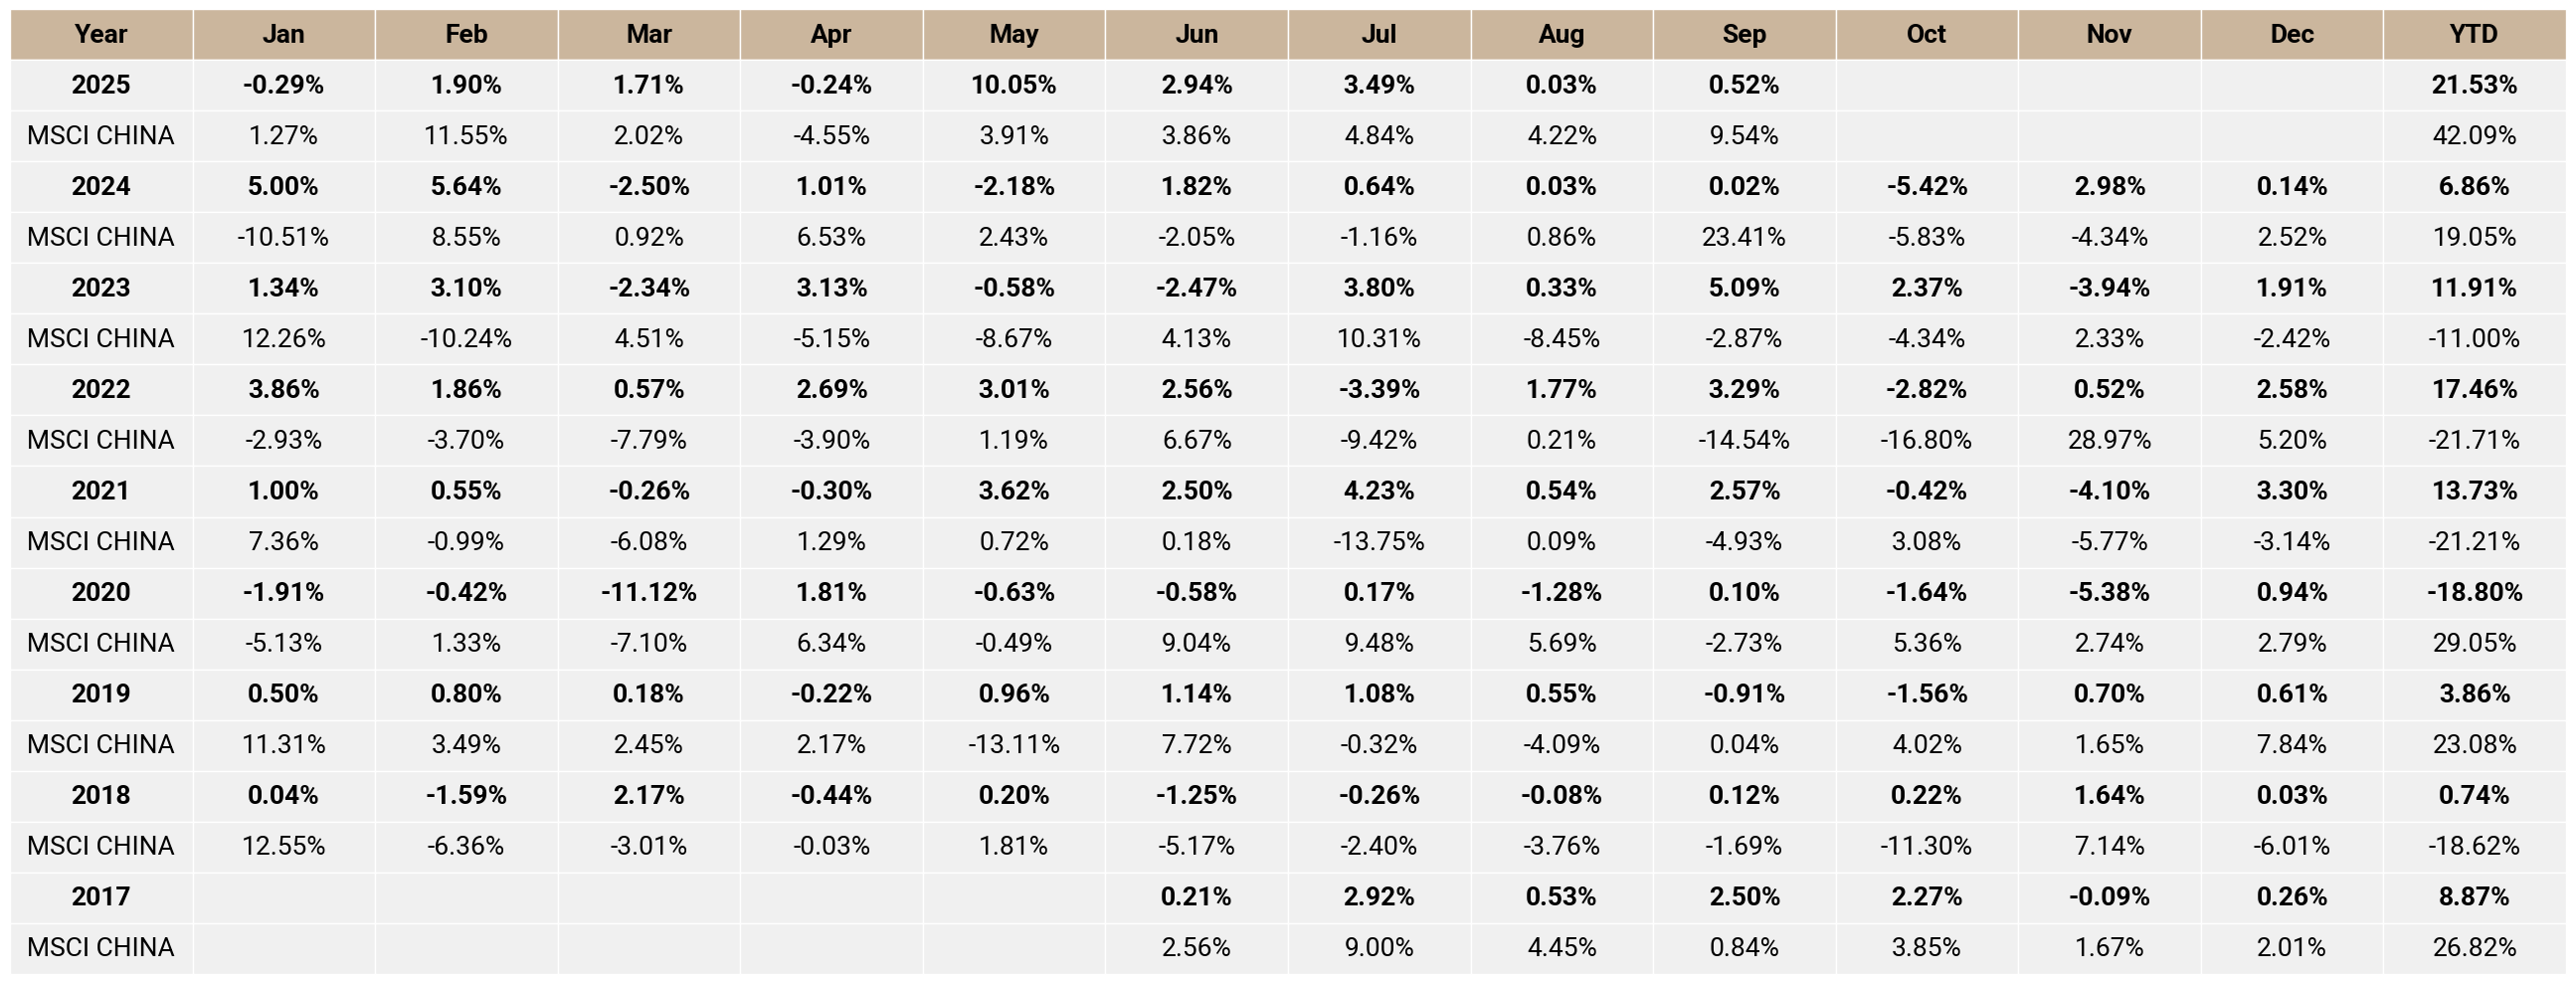

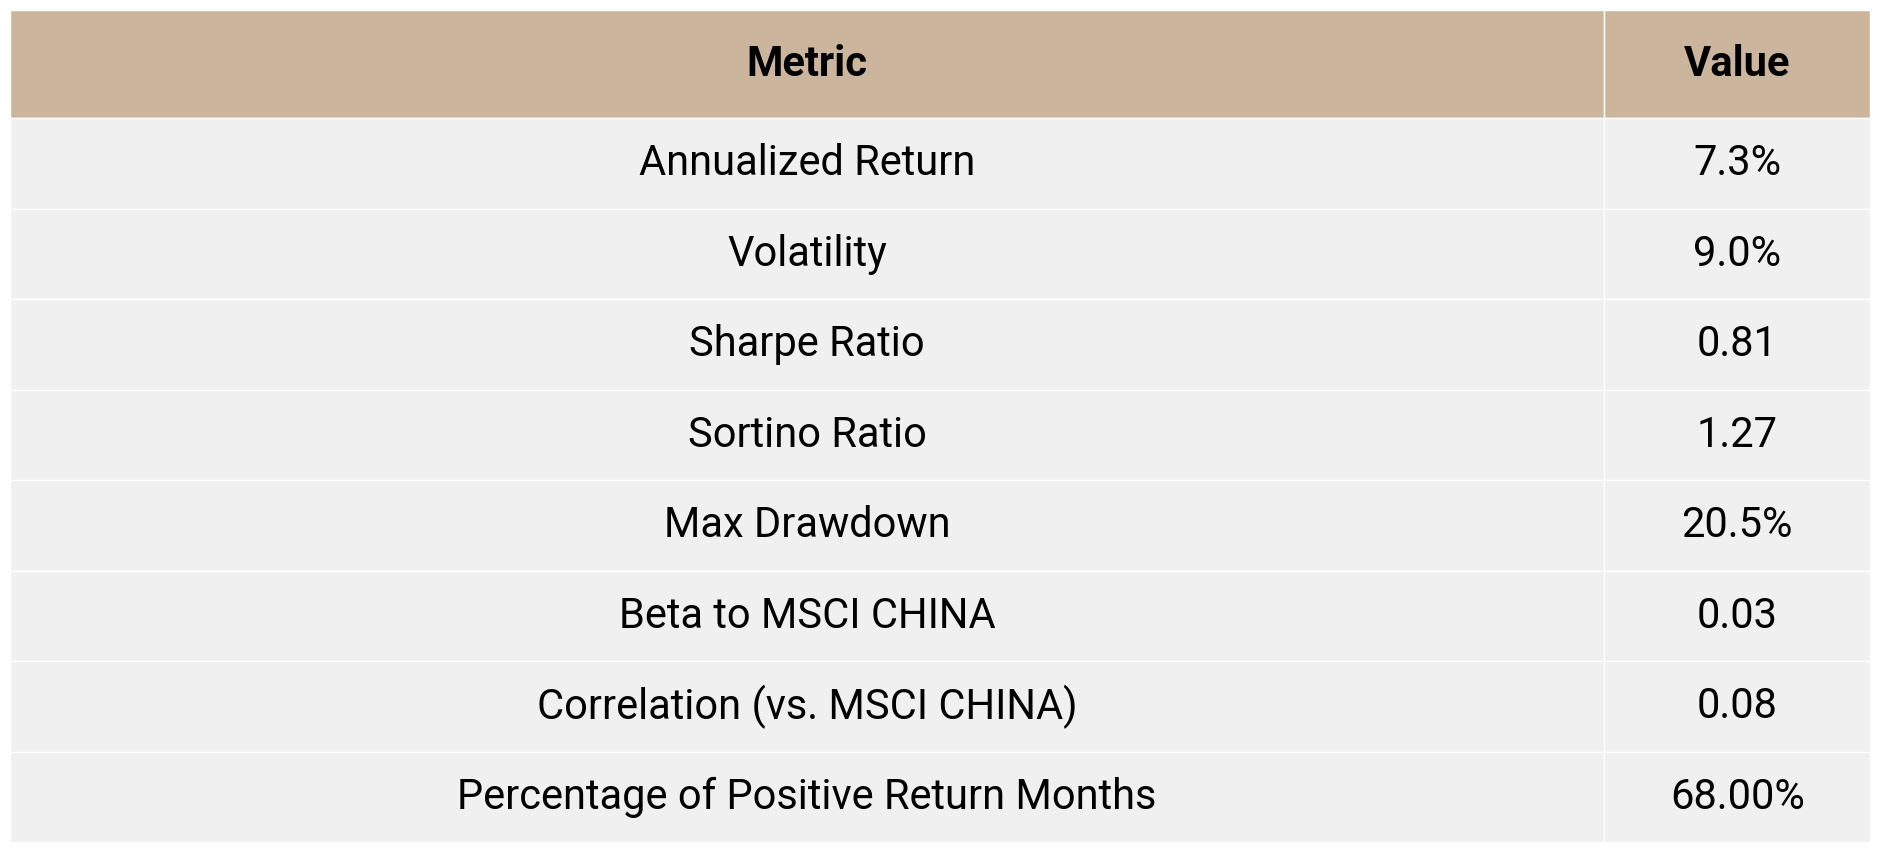

C:\Users\FOF Analyst\Desktop\fofproject\src\fofproject\fund.py:1582: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



In [10]:
# for f in ['DC', 'PROTIUM OPPORTUNITIES', 'FORWARDEDGE', 'ALPHA OPPORTUNITIES', 'ASIA ABSOLUTE', 'REGAL TACTICAL', 'PANVIEW', 'DKAM GLOBAL', 'AURIGIN', 'RDGFF', 'DUNAMIS', 'FRONTIER', 'HEL VED']:
funds['METRICA'].summary_of_a_fund(benchmark_fund=funds['MSCI CHINA'],language="en",save=True)

#### Quick Investigation

In [ ]:
the_fund_to_investigate = funds['RDGFF']
benchmark_fund = funds['MSCI CHINA']
# The List = ["cagr","vol","sharpe","sortino","mdd","beta","corr","win","best","worst","aum","skew","kurt","turnover"]

fig = the_fund_to_investigate.export_key_metrics_table(
            benchmark_fund=benchmark_fund,
            end_month=the_fund_to_investigate.latest_date,
            language="en",
            metrics=["cagr", "vol", "sharpe", "sortino", "mdd", "beta", "corr", "win"],
            horizontal=False,
        )